In [1]:
import pandas as pd
import random as rnd
import numpy as np
import math

rnd.seed(42)

In [2]:
# CSV (Comma Seperated Value) dosya tipindeki veri setini okuma
data = pd.read_csv("data/healthcare-dataset-stroke-data.csv")

In [3]:
data.head(50)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


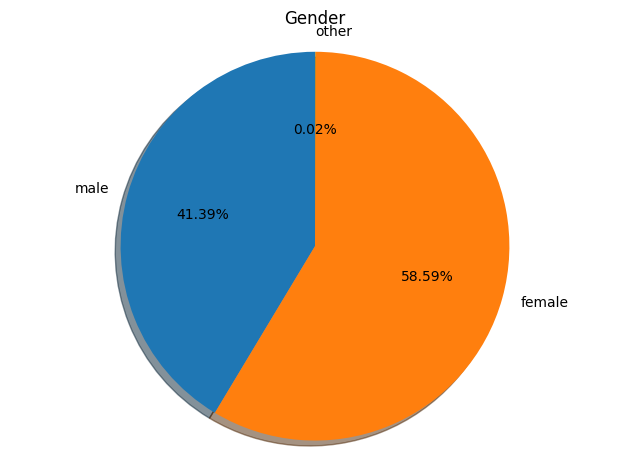

In [4]:
import matplotlib.pyplot as plt


labels = ['male', 'female','other']
genderCount= data['gender'].value_counts()
maleperc='{:.2f}'.format(genderCount["Male"]/data['gender'].count()*100)
femaleperc='{:.2f}'.format(genderCount["Female"]/data['gender'].count()*100)
otherperc='{:.2f}'.format(genderCount["Other"]/data['gender'].count()*100)

sizes = [maleperc, femaleperc, otherperc]


fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, autopct='%1.2f%%',
        shadow=True, startangle=90)
# Equal aspect ratio ensures that pie is drawn as a circle
ax1.axis('equal')  

ax1.set_title("Gender")
plt.tight_layout()
plt.show()

58.59% of the patients are female, 41.39% are male, and 0.02% are other.

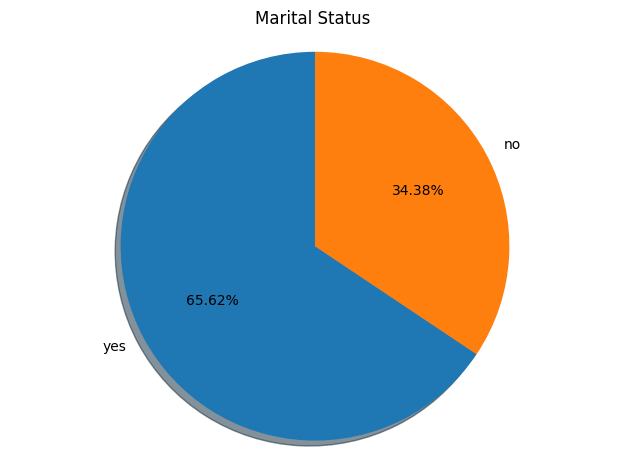

In [5]:
labels = ['yes', 'no']
ever_marriedCount= data['ever_married'].value_counts()
yesperc='{:.2f}'.format(ever_marriedCount["Yes"]/data['ever_married'].count()*100)
noperc='{:.2f}'.format(ever_marriedCount["No"]/data['ever_married'].count()*100)


sizes = [yesperc,noperc]


fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, autopct='%1.2f%%',
        shadow=True, startangle=90)
# Equal aspect ratio ensures that pie is drawn as a circle
ax1.set_title("Marital Status ")
ax1.axis('equal')  
plt.tight_layout()
plt.show()

About 65.62% of the patients were ever married, and 34.38% had never been in a marriage.

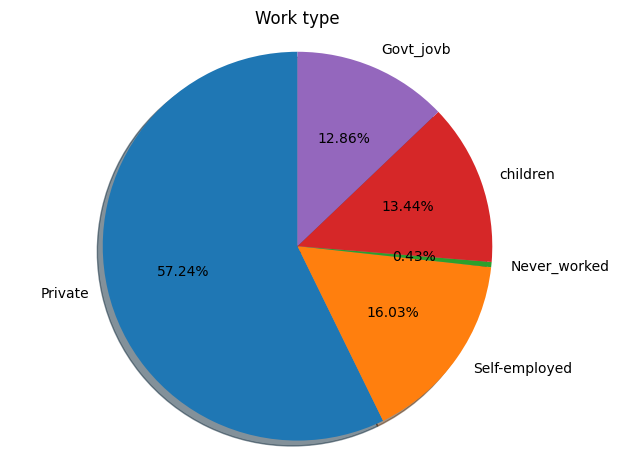

In [6]:
labels = ['Private', 'Self-employed',"Never_worked","children","Govt_jovb"]
occupationCount= data['work_type'].value_counts()
perc1='{:.2f}'.format(occupationCount["Private"]/data['work_type'].count()*100)
perc2='{:.2f}'.format(occupationCount["Self-employed"]/data['work_type'].count()*100)
perc3='{:.2f}'.format(occupationCount["Never_worked"]/data['work_type'].count()*100)
perc4='{:.2f}'.format(occupationCount["children"]/data['work_type'].count()*100)
perc5='{:.2f}'.format(occupationCount["Govt_job"]/data['work_type'].count()*100)

sizes = [perc1,perc2,perc3,perc4,perc5]


fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, autopct='%1.2f%%',
        shadow=True, startangle=90)
# Equal aspect ratio ensures that pie is drawn as a circle
ax1.set_title("Work type")
ax1.axis('equal')  
plt.tight_layout()
plt.show()

The majority of the patients are working in a private company

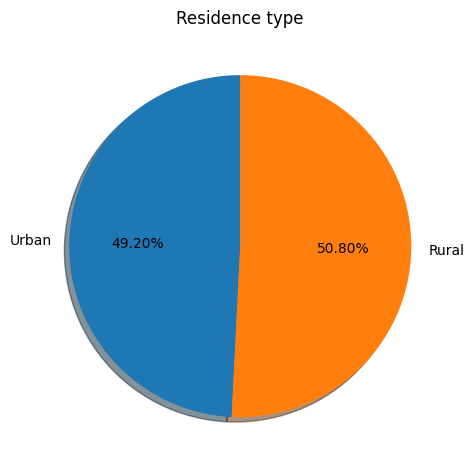

In [7]:

labels = ['Urban','Rural']
residenceCount= data['Residence_type'].value_counts()
perc1='{:.2f}'.format(residenceCount["Rural"]/data['Residence_type'].count()*100)
perc2='{:.2f}'.format(residenceCount["Urban"]/data['Residence_type'].count()*100)


sizes = [perc1,perc2]


fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, autopct='%1.2f%%',
        shadow=True, startangle=90)
# Equal aspect ratio ensures that pie is drawn as a circle
ax1.set_title("Residence type")

plt.tight_layout()
plt.show()

About 50.80% of the patients live in urban neighborhoods. While the rest live in a rural neighborhood.

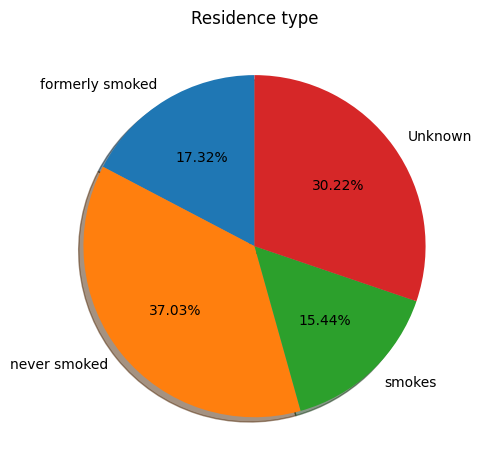

In [8]:
labels = ["formerly smoked","never smoked","smokes","Unknown"]
residenceCount= data['smoking_status'].value_counts()
perc1='{:.2f}'.format(residenceCount["formerly smoked"]/data['smoking_status'].count()*100)
perc2='{:.2f}'.format(residenceCount["never smoked"]/data['smoking_status'].count()*100)
perc3='{:.2f}'.format(residenceCount["smokes"]/data['smoking_status'].count()*100)
perc4='{:.2f}'.format(residenceCount["Unknown"]/data['smoking_status'].count()*100)


sizes = [perc1,perc2,perc3,perc4]


fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, autopct='%1.2f%%',
        shadow=True, startangle=90)
# Equal aspect ratio ensures that pie is drawn as a circle
ax1.set_title("Residence type")

plt.tight_layout()
plt.show()

The majority of the patients (37.03%) are non-smokers. The 'unknown' means the data is not available for that patient.

## Step1:  Exploratory Data Analysis (EDA)

### a) Preprocessing

In [9]:
#total number of rows :5110 
#tootal number of rows:12 (data has 11 attributes and one outcome)
data.shape

(5110, 12)

<Axes: xlabel='bmi', ylabel='Density'>

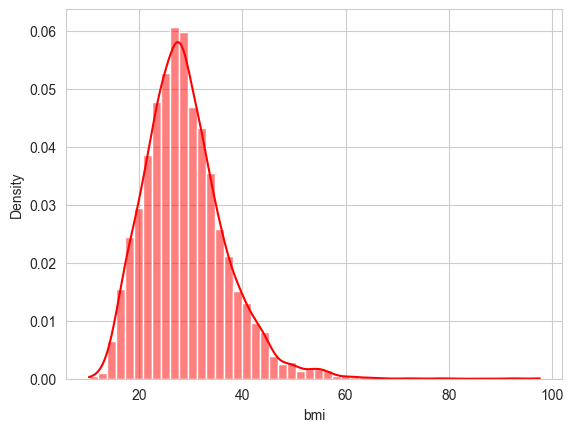

In [10]:
#distribution graphs 
import seaborn as sns
%matplotlib inline

sns.set_style('whitegrid')
sns.histplot(data['bmi'], color="red", label="100% Equities", kde=True, stat="density", linewidth=1,bins=50)

<Axes: xlabel='avg_glucose_level', ylabel='Density'>

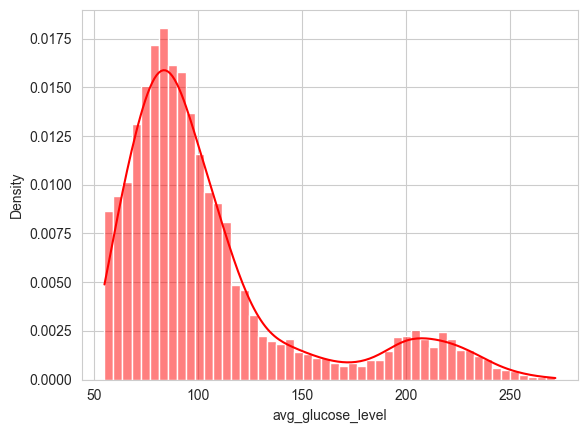

In [11]:

sns.histplot(data['avg_glucose_level'], color="red", label="100% Equities", kde=True, stat="density", linewidth=1,bins=50)

## Step2: Preprocessing & Feature Engineering 

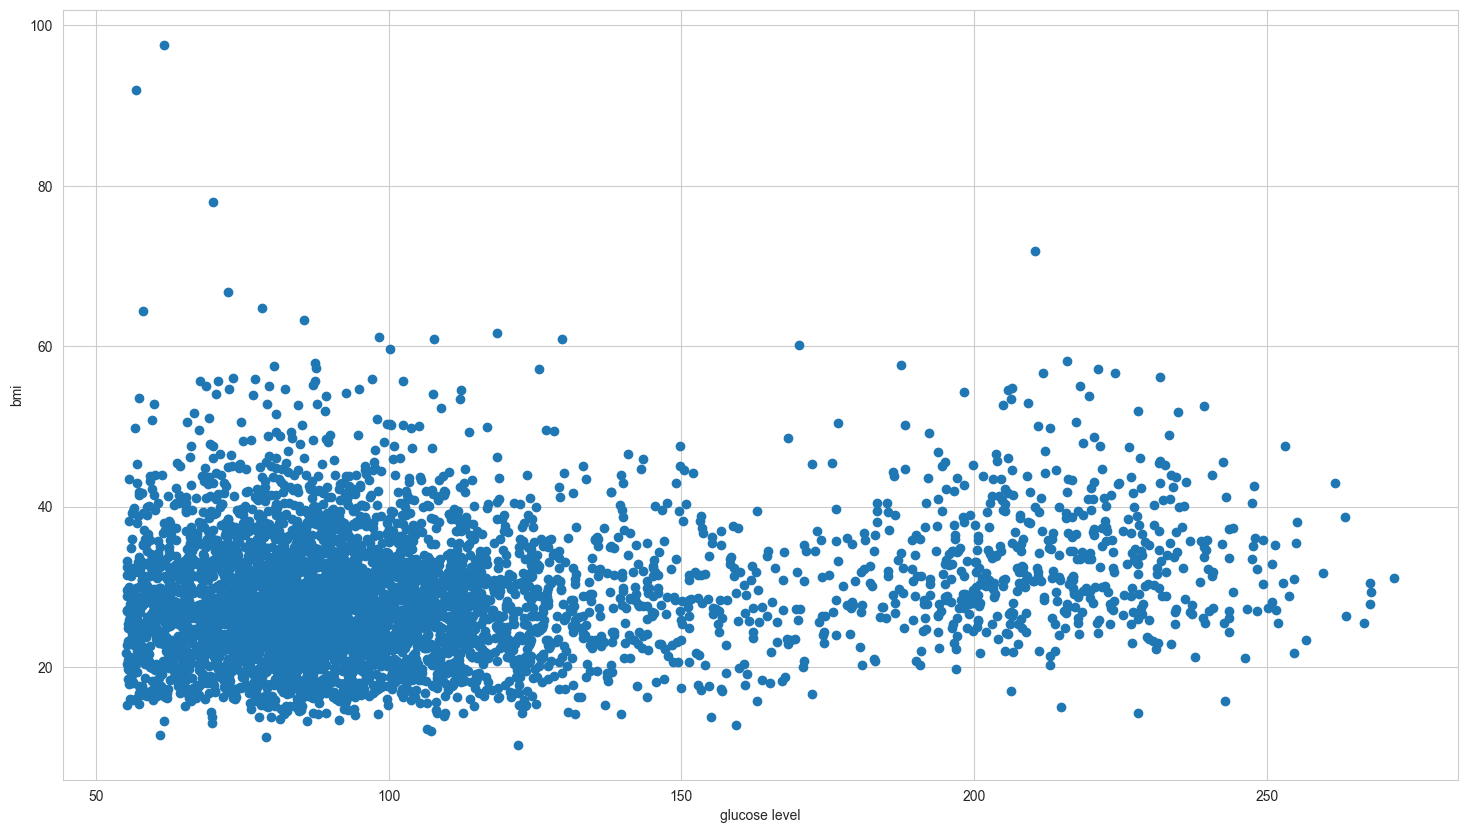

In [12]:

fig, ax = plt.subplots(figsize = (18,10))
ax.scatter(data['avg_glucose_level'], data['bmi'])
 
# x-axis label
ax.set_xlabel('glucose level')
 
# y-axis label
ax.set_ylabel('bmi')
plt.show()

In [13]:

def remove_outlier(df_in, col_name):
    if df_in[col_name].isnull().values.any() :
        Q1=np.nanpercentile(data[col_name], 25,
                   interpolation = 'midpoint')
        Q3=np.nanpercentile(data[col_name], 75,
                   interpolation = 'midpoint')
    else :
        Q1 = np.percentile(data[col_name], 25,
                   interpolation = 'midpoint')
        Q3 = np.percentile(data[col_name], 75,
                   interpolation = 'midpoint')
    iqr = Q3-Q1 #Interquartile range
    fence_low  = Q1-1.5*iqr
    fence_high = Q3+1.5*iqr
    df_out = df_in.loc[(df_in[col_name] > fence_low) & (df_in[col_name] < fence_high)]
    return df_out
   
    


In [14]:
data1=remove_outlier(data,"avg_glucose_level")
data = data1.reset_index(drop=True)
data.shape

C:\Users\DELL\AppData\Local\Temp\ipykernel_14332\4181728937.py:8: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  Q1 = np.percentile(data[col_name], 25,
C:\Users\DELL\AppData\Local\Temp\ipykernel_14332\4181728937.py:10: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  Q3 = np.percentile(data[col_name], 75,


(4483, 12)

In [15]:
#data2=remove_outlier(data1,"bmi")
#data = data2.reset_index(drop=True)
#data.shape

In [16]:
print("Özellik Bazlı Kayıp Değerlerin Sayısı:")
print(data.isnull().sum())

Özellik Bazlı Kayıp Değerlerin Sayısı:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  140
smoking_status         0
stroke                 0
dtype: int64


In [17]:
#bmi attribute has 140 missing value
#can t get rid of rows who have these missing data because it will be 
#big loss of important data 
#This method fills each missing row with the value of the nearest one above it.
data['bmi'].fillna(method='ffill', inplace=True)

In [18]:
print(data.isnull().sum())

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


there is missing data in gender column defined as "Other" 
Same for people with an "Unknown" smoking status, as unknown is the very definition of a missing value.

In [19]:
#The column ‘id’ doesn’t provide any useful context. So, we’ll drop it.
data = data.drop('id',axis=1)

In [20]:
(data["gender"]=="Other").sum()

1

In [21]:
data.loc[data['gender']=='Other']

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
2702,Other,26.0,0,0,No,Private,Rural,143.33,22.4,formerly smoked,0


In [22]:
#because we just find one row which has other as gender just dropped that one.
data=data.drop(3116,axis=0)
data=data.drop(2702,axis=0)
data.iloc[3114:3118,:]

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
3115,Female,65.0,0,0,No,Govt_job,Urban,60.70,31.3,never smoked,0
3117,Female,25.0,0,0,Yes,Private,Rural,79.94,36.6,Unknown,0
3118,Male,53.0,0,0,Yes,Govt_job,Rural,83.68,26.7,Unknown,0
3119,Female,50.0,0,0,Yes,Self-employed,Urban,69.92,18.7,formerly smoked,0


In [23]:
data = data.reset_index(drop=True)
data.iloc[3114:3118,:]

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
3114,Female,65.0,0,0,No,Govt_job,Urban,60.70,31.3,never smoked,0
3115,Female,25.0,0,0,Yes,Private,Rural,79.94,36.6,Unknown,0
3116,Male,53.0,0,0,Yes,Govt_job,Rural,83.68,26.7,Unknown,0
3117,Female,50.0,0,0,Yes,Self-employed,Urban,69.92,18.7,formerly smoked,0


In [24]:
#there is missing data in smoking_status column defined as unknown 
#since these data is unknown so 50% could be smoker and 50% may be not 
#so i replaced unknown with probably smokes so later i can give it order
#while encoding data

data['smoking_status']=data["smoking_status"].replace("Unknown", "probably smokes")
data['smoking_status'].value_counts()

smoking_status
never smoked       1632
probably smokes    1441
formerly smoked     723
smokes              685
Name: count, dtype: int64

In [25]:
#we need to  convert categorical data into integer format so that
# the data with converted categorical values can be provided to the
# models to give and improve the predictions
#obj_df = data.select_dtypes(include=['object']).copy()
dataclean = data.copy()

In [26]:
dataclean.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
1,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
2,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
3,Female,59.0,0,0,Yes,Private,Rural,76.15,22.8,probably smokes,1
4,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,probably smokes,1


In [27]:
#encoding (sıralama)
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
#symmetric
dataclean['gender']=le.fit_transform(dataclean['gender'])
dataclean['ever_married']=le.fit_transform(dataclean['ever_married'])
dataclean['work_type']=le.fit_transform(dataclean['work_type'])
dataclean['Residence_type']=le.fit_transform(dataclean['Residence_type'])
#obj_df['smoking_status']=le.fit_transform(obj_df['smoking_status'])

In [28]:
dataclean.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,80.0,0,1,1,2,0,105.92,32.5,never smoked,1
1,1,74.0,1,1,1,2,0,70.09,27.4,never smoked,1
2,0,69.0,0,0,0,2,1,94.39,22.8,never smoked,1
3,0,59.0,0,0,1,2,0,76.15,22.8,probably smokes,1
4,0,78.0,0,0,1,2,1,58.57,24.2,probably smokes,1


people who've never smoked are probably less likely to have a stroke than those who did smoke in the past, which in turn are less likely to have a stroke than those who currently smoke, we can say there is some inherent order to these three categories.
Thus, it would be meaningful to encode them with 0, 1, 2 & 3.
never smoked   =>0
probably smokes=>1
formerly smoked=>2
smoked         =>3

In [29]:
#asymmetric
smoking_mapper={"never smoked":0,"probably smokes":1,"formerly smoked":2,"smokes":3}

In [30]:
cleanup_nums = {"smoking_status": {"never smoked":0,"probably smokes":1,"formerly smoked":2,"smokes":3}}

In [31]:
dataclean = dataclean.replace(cleanup_nums)
dataclean.iloc[3114:3118,:]

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
3114,0,65.0,0,0,0,0,1,60.70,31.3,0,0
3115,0,25.0,0,0,1,2,0,79.94,36.6,1,0
3116,1,53.0,0,0,1,0,0,83.68,26.7,1,0
3117,0,50.0,0,0,1,3,1,69.92,18.7,2,0


In [32]:
data=dataclean.copy()


### b) Feature Engineering

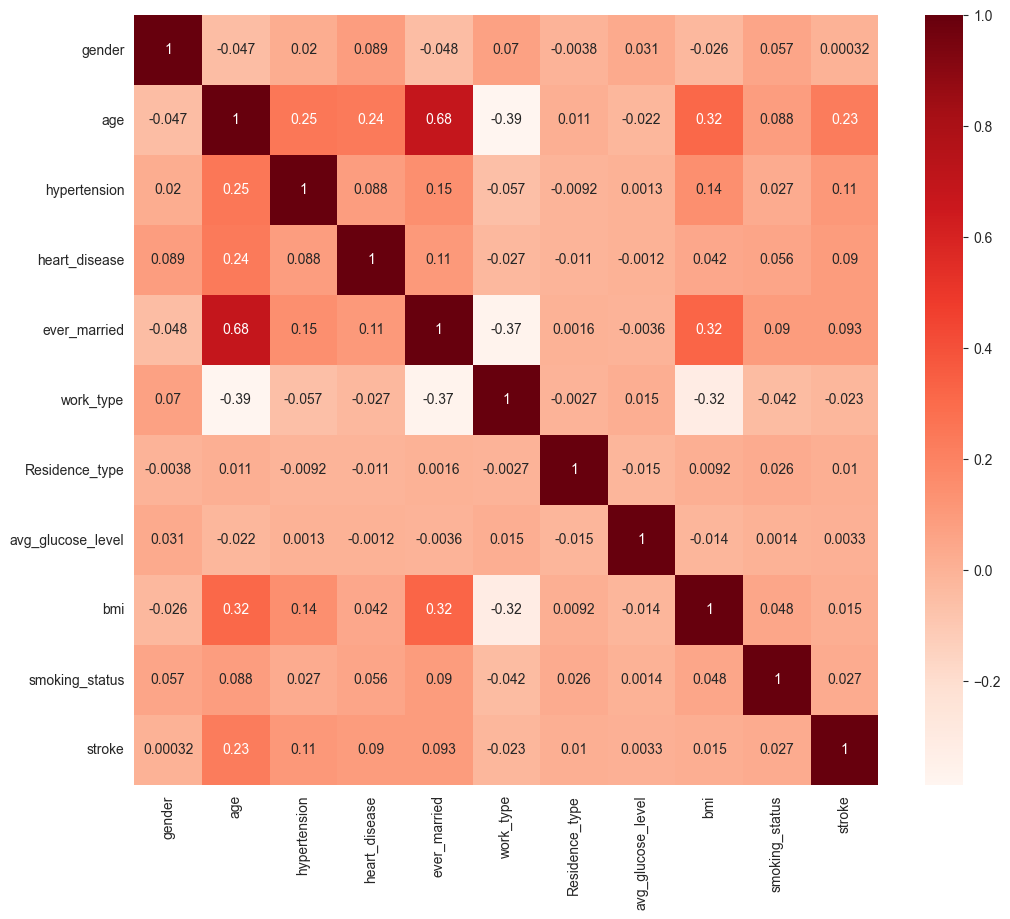

In [33]:
#Using Pearson Correlation
#Determine which features are the most valuable
plt.figure(figsize=(12,10))
cor = data.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)
plt.show()

In [34]:
# Discretize with respective equal-width bin
dataclean['age_binned'] = pd.cut(dataclean['age'], np.arange(0, 91, 5))
dataclean['avg_glucose_level_binned'] = pd.cut(dataclean['avg_glucose_level'], np.arange(0, 301, 20))
dataclean['bmi_binned'] = pd.cut(dataclean['bmi'], np.arange(0, 101, 5))

In [35]:

def get_stacked_bar_chart(column):
    # Get the count of records by column and stroke    
    df_pct = dataclean.groupby([column, 'stroke'])['age'].count()
    # Create proper DataFrame's format
    df_pct = df_pct.unstack()    
    return df_pct.plot.bar(stacked=True, figsize=(6,6), width=1);


In [36]:
def get_100_percent_stacked_bar_chart(column, width = 0.5):
    # Get the count of records by column and stroke
    df_breakdown = dataclean.groupby([column, 'stroke'])['age'].count()
    # Get the count of records by gender
    df_total = dataclean.groupby([column])['age'].count()
    # Get the percentage for 100% stacked bar chart
    df_pct = df_breakdown / df_total * 100
    # Create proper DataFrame's format
    df_pct = df_pct.unstack()
    return df_pct.plot.bar(stacked=True, figsize=(6,6), width=width);

<Axes: xlabel='Residence_type'>

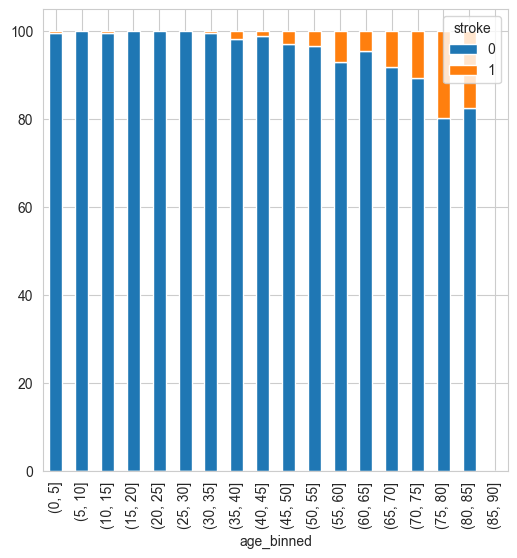

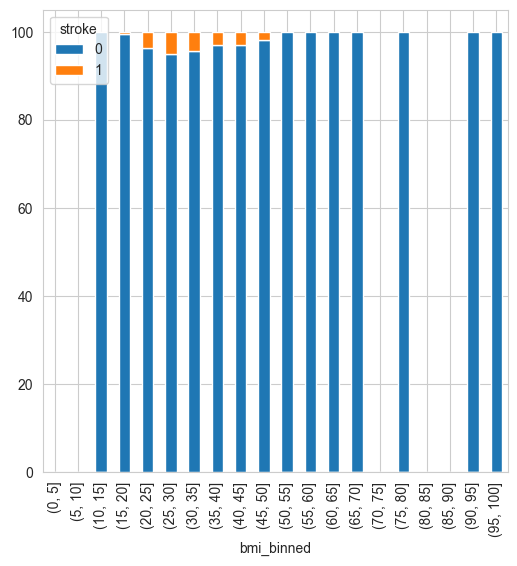

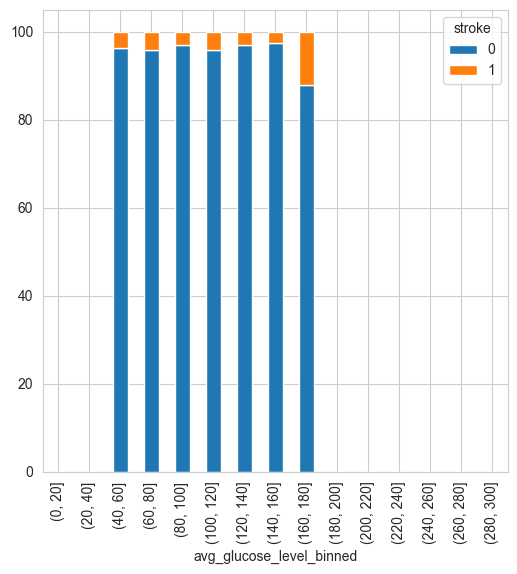

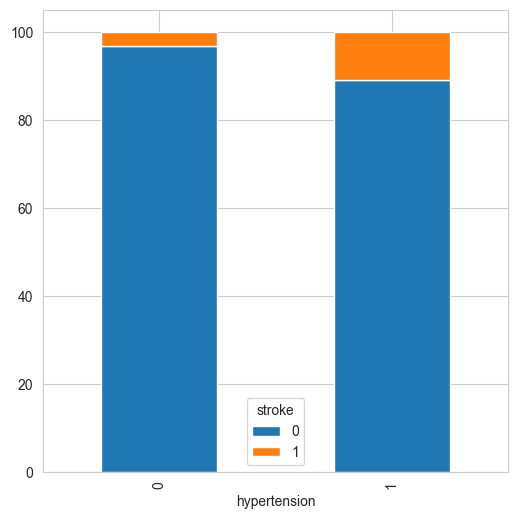

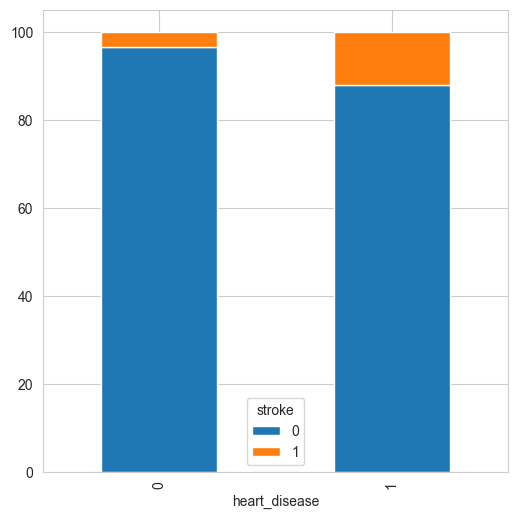

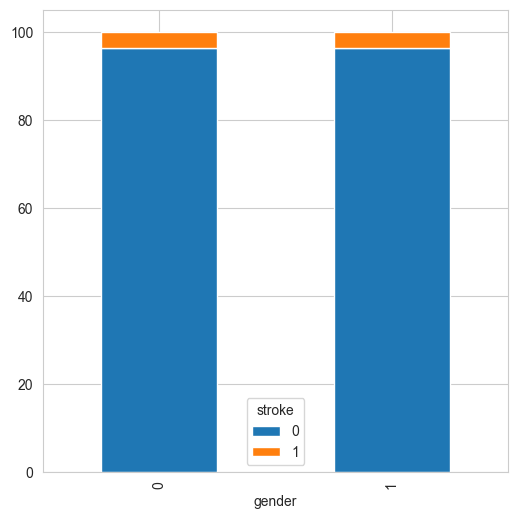

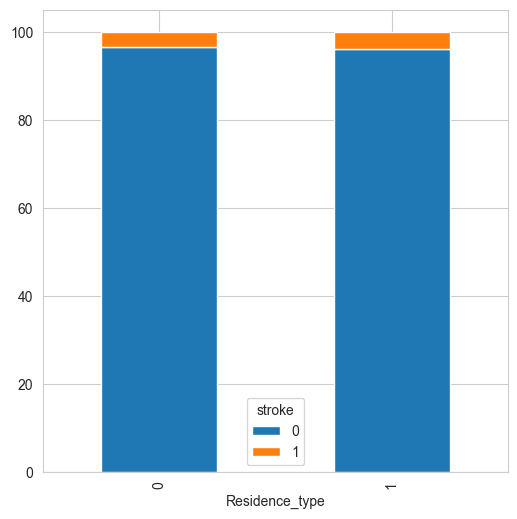

In [37]:
get_100_percent_stacked_bar_chart('age_binned')
get_100_percent_stacked_bar_chart('bmi_binned')
get_100_percent_stacked_bar_chart('avg_glucose_level_binned')
get_100_percent_stacked_bar_chart('hypertension')
get_100_percent_stacked_bar_chart('heart_disease')
get_100_percent_stacked_bar_chart('gender')
get_100_percent_stacked_bar_chart('Residence_type')

- The risk of experiencing a stroke increased as patient’s age advanced.
=>Older patient was more likely to suffer a stroke than a younger patient.
- Percentage of patient who had BMI between 25 and 35 was the highest to suffer a stroke than patients from other groups.
=>Higher BMI does not increase the stroke risk.
- stroke incidence occurred to some patients regardless of the average glucose level measured after meal. Although there was no stroke incidence reported on the last two columns on the right, these columns were represented by only 3 patients, i.e. not significant. Nevertheless, higher proportion of patient who had average glucose level measured after meal of more than 150mg/dL (milligrams per decilitre) suffered a stroke. This observation can be explained by the presence of diabetes. Diabetes was present in patient who had reading of more than 200mg/dL. Pre-diabetes was also considered in patient if the reading was between 140–199mg/dL.
=> Diabetes is one of the risk factors for stroke occurrence and prediabetes patients have an increased risk of stroke.
Higher proportion of patients who suffered from hypertension or heart disease experienced a stroke, all else being equal.
- Regardless of patient’s gender, and where they stayed, they have the same likelihood to experience stroke.

## Step3:  Choose Data Mining Algorithms & Explain

In [38]:
# cross validation
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.model_selection import KFold,cross_val_score

X = data.drop('stroke',axis=1)
Y = data.stroke

LR = LinearRegression()
DTR = DecisionTreeRegressor()
RFR = RandomForestClassifier()    
KNR = KNeighborsRegressor()

kf = KFold(n_splits=10,shuffle=True,random_state=10)

print(f" Linear Regression : {np.sqrt(-cross_val_score(LR,X,Y,cv=kf,scoring='neg_mean_squared_error').mean())}")
print(f" Decision Tree : {np.sqrt(-cross_val_score(DTR,X,Y,cv=kf,scoring='neg_mean_squared_error').mean())}")
print(f" Random Forest : {np.sqrt(-cross_val_score(RFR,X,Y,cv=kf,scoring='neg_mean_squared_error').mean())}")

print(f" KNeighbors : {np.sqrt(-cross_val_score(KNR,X,Y,cv=kf,scoring='neg_mean_squared_error').mean())}")

 Linear Regression : 0.1825241320360032
 Decision Tree : 0.2742367854764044
 Random Forest : 0.1924697975571313
 KNeighbors : 0.19856659019414608


## Step4:  Algorithms, Implementation and Performance Comparison

#### Random Forest

In [39]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier



In [40]:
#Separating input and target data
X = data.drop(['stroke'],axis=1)
Y = data['stroke']
#Printing shapes of input and target
print('X Shape', X.shape)
print('Y Shape',Y.shape)
from collections import Counter
counter = Counter(Y)
print(counter)

X Shape (4481, 10)
Y Shape (4481,)
Counter({0: 4316, 1: 165})


In [41]:
# the number of 0’s and 1’s in stroke ‘column’.
data['stroke'].value_counts()

stroke
0    4316
1     165
Name: count, dtype: int64

there is a class imbalance problem here as there are 4314 cases of stroke but only 165 cases of no-stroke. 


In [42]:
#handle class imbalance problem
smote = SMOTE(sampling_strategy=0.3)
X, Y = smote.fit_resample(X, Y)

In [43]:
print('X Shape', X.shape)
print('Y Shape',Y.shape)

X Shape (5610, 10)
Y Shape (5610,)


In [44]:
from collections import Counter

counter = Counter(Y)
print(counter)

Counter({0: 4316, 1: 1294})


In [45]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

In [46]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

model_rfc = RandomForestClassifier()
model_rfc.fit(x_train,y_train)
prediction_rfc=model_rfc.predict(x_test)

print(confusion_matrix(y_test, prediction_rfc))
print(classification_report(y_test, prediction_rfc))

[[846  25]
 [ 43 208]]
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       871
           1       0.89      0.83      0.86       251

    accuracy                           0.94      1122
   macro avg       0.92      0.90      0.91      1122
weighted avg       0.94      0.94      0.94      1122



In [47]:
#model’s score on test data. 
#the model correctly predicts 94% of the target values.
 #model.score(x_test,y_test)
roc_rfc_1 = roc_auc_score(y_test, prediction_rfc) 
roc_rfc_1

0.8999913091606022

#### Logistic regression

In [48]:
from sklearn.linear_model import LogisticRegression
logmodel = LogisticRegression(solver='lbfgs', max_iter=1000)
logmodel.fit(x_train,y_train)


LogisticRegression(max_iter=1000)

In [49]:
predictions = logmodel.predict(x_test)

In [50]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90       871
           1       0.68      0.56      0.62       251

    accuracy                           0.84      1122
   macro avg       0.78      0.74      0.76      1122
weighted avg       0.84      0.84      0.84      1122



In [51]:
logmodel.score(x_test, y_test)
roc_lr_1 = roc_auc_score(y_test, predictions) 
roc_lr_1

0.7429890083752247

In [52]:
from sklearn.metrics import confusion_matrix
#sns.heatmap(confusion_matrix(y_test,predictions), annot= True, cmap = 'viridis', fmt="2")
#plt.title('Confusion Matrix')
#plt.show()

#### Logistic regression improvment

In [53]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_scaled = sc.fit_transform(x_train)
X_test_scaled = sc.transform (x_test)

In [54]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
param_grid_lr = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000], 'penalty': ['l2'], 'max_iter': list(range(100,800,100)), 'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']}

log1 = LogisticRegression()
logmodel1 = RandomizedSearchCV(log1, param_grid_lr, cv = 5)
logmodel1.fit(X_train_scaled, y_train)
logprediction1 = logmodel1.best_estimator_.predict(X_test_scaled)

print("Tuned Logistic Regression Parameters: {}".format(logmodel1.best_params_)) 
print("Best score is {}".format(logmodel1.best_score_))

print(confusion_matrix(y_test,logprediction1))
print(classification_report(y_test,logprediction1))

Tuned Logistic Regression Parameters: {'solver': 'newton-cg', 'penalty': 'l2', 'max_iter': 300, 'C': 0.1}
Best score is 0.8351150705270973
[[806  65]
 [112 139]]
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       871
           1       0.68      0.55      0.61       251

    accuracy                           0.84      1122
   macro avg       0.78      0.74      0.76      1122
weighted avg       0.83      0.84      0.84      1122



In [55]:
roc_lr_2 = roc_auc_score(y_test, logprediction1) 
roc_lr_2

0.7395789974430635

Hyperparameter tuning did not improve the performance of the logistic regression model.

#### Random Forest improvment

In [56]:
param_grid_rfc = {'bootstrap': [True, False], 'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, None], 'max_features': ['auto', 'sqrt'], 'min_samples_leaf': [1, 2, 4], 'min_samples_split': [2, 5, 10], 'n_estimators': [130, 180, 230]}
rfc_2 =RandomForestClassifier()
rfc_2_model = RandomizedSearchCV(rfc_2, param_grid_rfc, cv = 5)
rfc_2_model.fit(x_train, y_train)
prediction_rfc_2 = rfc_2_model.best_estimator_.predict(x_test)

print("Tuned RFC Parameters: {}".format(rfc_2_model.best_params_)) 
print("Best score is {}".format(rfc_2_model.best_score_))

print(confusion_matrix(y_test, prediction_rfc_2))
print(classification_report(y_test,prediction_rfc_2))

C:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
20 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py", line 1145, in wrapper
    estimator._validate_params()
  File "C:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py", l

Tuned RFC Parameters: {'n_estimators': 180, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 80, 'bootstrap': False}
Best score is 0.9304784818486764
[[846  25]
 [ 41 210]]
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       871
           1       0.89      0.84      0.86       251

    accuracy                           0.94      1122
   macro avg       0.92      0.90      0.91      1122
weighted avg       0.94      0.94      0.94      1122



In [57]:
roc_rfc_2 = roc_auc_score(y_test, prediction_rfc_2) 
roc_rfc_2

0.9039753729056221

## Step5:  Further Performance Improvement 
i propose other improvement technique called gradient boosting classifier

In [58]:
from sklearn.ensemble import GradientBoostingClassifier
gbc_1 = GradientBoostingClassifier()
gbc_1.fit(x_train, y_train)
prediction_gbc_1 = gbc_1.predict(x_test)

print(confusion_matrix(y_test, prediction_gbc_1))
print(classification_report(y_test,prediction_gbc_1))

[[844  27]
 [ 93 158]]
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       871
           1       0.85      0.63      0.72       251

    accuracy                           0.89      1122
   macro avg       0.88      0.80      0.83      1122
weighted avg       0.89      0.89      0.89      1122



In [59]:
roc_gbc_1 = roc_auc_score(y_test, prediction_gbc_1) 
roc_gbc_1

0.7992416099093865

In [60]:
param_grid_gbc = {'n_estimators':[10, 100, 1000], 'learning_rate': [0.001, 0.01, 0.1], 'subsample': [0.5, 0.7, 1.0], 'max_depth': [3, 7, 9]}
gbc_2 = GradientBoostingClassifier()
gbc_2_model = RandomizedSearchCV(gbc_2, param_grid_gbc, cv = 5)
gbc_2_model.fit(x_train, y_train)
prediction_gbc_2 = gbc_2_model.best_estimator_.predict(x_test)

print("Tuned GBC Parameters: {}".format(gbc_2_model.best_params_)) 
print("Best score is {}".format(gbc_2_model.best_score_))

print(confusion_matrix(y_test, prediction_gbc_2))
print(classification_report(y_test,prediction_gbc_2))

Tuned GBC Parameters: {'subsample': 1.0, 'n_estimators': 1000, 'max_depth': 9, 'learning_rate': 0.1}
Best score is 0.9536534799244201
[[860  11]
 [ 40 211]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       871
           1       0.95      0.84      0.89       251

    accuracy                           0.95      1122
   macro avg       0.95      0.91      0.93      1122
weighted avg       0.95      0.95      0.95      1122



In [61]:
roc_gbc_2 = roc_auc_score(y_test, prediction_gbc_2) 
roc_gbc_2

0.914004144158155

In [62]:
import pickle

# save model
with open("stroke_model.pkl", "wb") as file:
    pickle.dump(rfc_2_model.best_estimator_, file)

In [63]:
with open("logistic_model.pkl", "wb") as file:
    pickle.dump(logmodel1.best_estimator_, file)

In [64]:
with open("scaler.pkl", "wb") as file:
    pickle.dump(sc, file)

In [65]:
import pickle

# load model
with open("stroke_model.pkl", "rb") as file:
    model = pickle.load(file)

# load scaler
with open("scaler.pkl", "rb") as file:
    scaler = pickle.load(file)

In [66]:
pickle.dump(model_rfc, open("random_forest.pkl","wb"))
pickle.dump(logmodel, open("logistic.pkl","wb"))
pickle.dump(gbc_1, open("gradient_boost.pkl","wb"))